In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


In [104]:
# Load the consolidated stock data
stock_path = '/Users/asifmddev/Home Workspace/IIT Mandi/Capstone/Capstone Project/Stock_Data/'
df = pd.read_csv(stock_path + 'NIFTY50_all.csv')

# Load Nifty 50 benchmark data
benchmark_path = '/Users/asifmddev/Home Workspace/IIT Mandi/Capstone/Capstone Project/Additional data/'
nifty = pd.read_csv(benchmark_path + 'Nifty_Benchmark.csv')

print("Data loaded successfully")
print(f"Stock data shape: {df.shape}")
print(f"Nifty benchmark shape: {nifty.shape}")

Data loaded successfully
Stock data shape: (235192, 15)
Nifty benchmark shape: (1475, 6)


In [105]:
# Convert Date columns to datetime format
df['Date'] = pd.to_datetime(df['Date'])
nifty['Date'] = pd.to_datetime(nifty['Date'])

# Filter data from 2016-2020 only (5 years of complete data)
df = df[(df['Date'] >= '2016-01-01') & (df['Date'] <= '2020-12-31')].copy()
nifty = nifty[(nifty['Date'] >= '2016-01-01') & (nifty['Date'] <= '2020-12-31')].copy()

# Sort data by Symbol and Date
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)
nifty = nifty.sort_values('Date').reset_index(drop=True)

# Handle missing values using forward fill method
df['Close'] = df.groupby('Symbol')['Close'].fillna(method='ffill')

# Remove duplicate records
df = df.drop_duplicates(subset=['Date', 'Symbol'])

print("Data cleaning completed")
print(f"Stock data: {df.shape[0]} rows from {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total unique stocks: {df['Symbol'].nunique()}")
print(f"Nifty benchmark: {nifty.shape[0]} rows")

Data cleaning completed
Stock data: 60662 rows from 2016-01-01 to 2020-12-31
Total unique stocks: 49
Nifty benchmark: 1228 rows


In [106]:
# Calculate daily returns for each stock
# Formula: (Today's Close - Yesterday's Close) / Yesterday's Close
df = df.sort_values(['Symbol', 'Date'])
df['Daily_Return'] = df.groupby('Symbol')['Close'].pct_change()

# Remove rows with NaN returns (first day of each stock)
df = df.dropna(subset=['Daily_Return'])

# Calculate returns for Nifty benchmark
nifty = nifty.sort_values('Date')
nifty['Nifty_Return'] = nifty['Close'].pct_change()
nifty = nifty.dropna(subset=['Nifty_Return'])

print("Daily returns calculated")
print(f"Total records with returns: {len(df)}")
print("\nSample data:")
print(df[['Date', 'Symbol', 'Close', 'Daily_Return']].head(10))

Daily returns calculated
Total records with returns: 60613

Sample data:
         Date      Symbol    Close  Daily_Return
1  2016-01-04  ADANIPORTS 257.9500       -0.0359
2  2016-01-05  ADANIPORTS 255.7000       -0.0087
3  2016-01-06  ADANIPORTS 251.8000       -0.0153
4  2016-01-07  ADANIPORTS 245.0000       -0.0270
5  2016-01-08  ADANIPORTS 241.4000       -0.0147
6  2016-01-11  ADANIPORTS 234.0500       -0.0304
7  2016-01-12  ADANIPORTS 236.6000        0.0109
8  2016-01-13  ADANIPORTS 230.2000       -0.0270
9  2016-01-14  ADANIPORTS 227.8000       -0.0104
10 2016-01-15  ADANIPORTS 218.2500       -0.0419


In [107]:
# Create a summary dataframe for each stock
stock_list = []

for symbol in df['Symbol'].unique():
    stock_data = df[df['Symbol'] == symbol].copy()
    
    first_close = stock_data['Close'].iloc[0]
    last_close = stock_data['Close'].iloc[-1]
    
    metrics = {
        'Symbol': symbol,
        'First_Close': first_close,
        'Last_Close': last_close,
        'Mean_Return': stock_data['Daily_Return'].mean(),
        'Median_Return': stock_data['Daily_Return'].median(),
        'Std_Return': stock_data['Daily_Return'].std(),
        'Min_Return': stock_data['Daily_Return'].min(),
        'Max_Return': stock_data['Daily_Return'].max(),
        'Days': len(stock_data)
    }
    
    stock_list.append(metrics)

# Convert to dataframe
stock_metrics = pd.DataFrame(stock_list)

# Calculate cumulative return over the entire period
stock_metrics['Cumulative_Return'] = ((stock_metrics['Last_Close'] - stock_metrics['First_Close']) 
                                       / stock_metrics['First_Close']) * 100

# Calculate annualized return (252 trading days per year)
stock_metrics['Annualized_Return'] = ((1 + stock_metrics['Mean_Return']) ** 252 - 1) * 100

# Calculate annualized volatility
stock_metrics['Annualized_Volatility'] = stock_metrics['Std_Return'] * np.sqrt(252) * 100

# Sort by cumulative return descending
stock_metrics = stock_metrics.sort_values('Cumulative_Return', ascending=False).reset_index(drop=True)

print("Stock metrics calculated")
print(f"Total stocks analyzed: {len(stock_metrics)}")
print("\nTop 10 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].head(10))
print("\nBottom 5 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].tail(5))


Stock metrics calculated
Total stocks analyzed: 49

Top 10 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
0  BAJAJFINSV           354.5216            45.4306                36.7224
1       TITAN           345.9732            43.5593                34.0834
2   NESTLEIND           224.3545            30.5611                25.0529
3  ASIANPAINT           213.8624            30.5339                25.6860
4    HINDALCO           197.8947            34.8315                41.6577
5   KOTAKBANK           182.9434            27.8717                28.3728
6  HINDUNILVR           178.8591            26.6794                23.3891
7   TATASTEEL           150.5450            29.6757                38.3201
8    SHREECEM           117.1313            21.8721                30.2726
9        HDFC           110.2942            20.8329                29.8451

Bottom 5 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
44   JS

In [108]:
# Keep only top 50 stocks by number of trading days (most complete data)
stock_metrics = stock_metrics.sort_values('Days', ascending=False).head(50).reset_index(drop=True)

# Re-sort by cumulative return
stock_metrics = stock_metrics.sort_values('Cumulative_Return', ascending=False).reset_index(drop=True)

print(f"Filtered to top 50 stocks with most complete data")
print(f"\nTop 10 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].head(10))
print("\nBottom 5 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].tail(5))

Filtered to top 50 stocks with most complete data

Top 10 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
0  BAJAJFINSV           354.5216            45.4306                36.7224
1       TITAN           345.9732            43.5593                34.0834
2   NESTLEIND           224.3545            30.5611                25.0529
3  ASIANPAINT           213.8624            30.5339                25.6860
4    HINDALCO           197.8947            34.8315                41.6577
5   KOTAKBANK           182.9434            27.8717                28.3728
6  HINDUNILVR           178.8591            26.6794                23.3891
7   TATASTEEL           150.5450            29.6757                38.3201
8    SHREECEM           117.1313            21.8721                30.2726
9        HDFC           110.2942            20.8329                29.8451

Bottom 5 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
44   JSW

In [109]:
# Define sector mapping for major Nifty stocks
sector_map = {
    'TCS': 'IT', 'INFY': 'IT', 'WIPRO': 'IT', 'HCLTECH': 'IT', 'TECHM': 'IT',
    'RELIANCE': 'Energy', 'ONGC': 'Energy', 'BPCL': 'Energy', 'IOC': 'Energy',
    'HDFCBANK': 'Banking', 'ICICIBANK': 'Banking', 'SBIN': 'Banking', 'AXISBANK': 'Banking', 
    'KOTAKBANK': 'Banking', 'INDUSINDBK': 'Banking',
    'HINDUNILVR': 'FMCG', 'ITC': 'FMCG', 'NESTLEIND': 'FMCG', 'BRITANNIA': 'FMCG',
    'SUNPHARMA': 'Pharma', 'DRREDDY': 'Pharma', 'CIPLA': 'Pharma', 'DIVISLAB': 'Pharma',
    'TATAMOTORS': 'Auto', 'M&M': 'Auto', 'BAJAJ-AUTO': 'Auto', 'MARUTI': 'Auto', 'EICHERMOT': 'Auto',
    'BAJAJFINSV': 'Financial', 'BAJFINANCE': 'Financial', 'BAJAJFINSERV': 'Financial',
    'TATASTEEL': 'Metals', 'HINDALCO': 'Metals', 'JSWSTEEL': 'Metals', 'COALINDIA': 'Metals',
    'LT': 'Infrastructure', 'ULTRACEMCO': 'Cement', 'ADANIPORTS': 'Infrastructure',
    'SHREECEM': 'Cement', 'SHREECEMN': 'Cement', 'GRASIM': 'Cement',
    'BHARTIARTL': 'Telecom', 'POWERGRID': 'Power', 'NTPC': 'Power',
    'ASIANPAINT': 'Paint', 'TITAN': 'Consumer', 'HEROMOTOCO': 'Auto',
    'BAJAUTOFIN': 'Financial', 'HINDLEVER': 'FMCG', 'INFOSYSTCH': 'IT',
    'MUNDRAPORT': 'Infrastructure'
}

# Add sector information to stock metrics
stock_metrics['Sector'] = stock_metrics['Symbol'].map(sector_map).fillna('Others')

# Selection strategy: Top 10 + Bottom 5 + ensure sector diversity
top_10_stocks = stock_metrics.head(10)['Symbol'].tolist()
bottom_5_stocks = stock_metrics.tail(5)['Symbol'].tolist()

# Combine initial selection
selected_stocks = list(set(top_10_stocks + bottom_5_stocks))
selected_df = stock_metrics[stock_metrics['Symbol'].isin(selected_stocks)].copy()

# Check sector coverage
sectors_covered = selected_df['Sector'].nunique()
print(f"Initial selection: {len(selected_stocks)} stocks from {sectors_covered} sectors")

# If we need more stocks or sector diversity, add mid-performers from underrepresented sectors
if len(selected_stocks) < 12 or sectors_covered < 4:
    remaining = stock_metrics[~stock_metrics['Symbol'].isin(selected_stocks)]
    priority_sectors = ['IT', 'Banking', 'Pharma', 'FMCG', 'Energy', 'Auto']
    
    for sector in priority_sectors:
        if sector not in selected_df['Sector'].values and len(selected_stocks) < 15:
            sector_stock = remaining[remaining['Sector'] == sector].head(1)
            if not sector_stock.empty:
                selected_stocks.append(sector_stock.iloc[0]['Symbol'])

# Final selection (limit to 15 stocks)
selected_stocks = selected_stocks[:15]
selected_metrics = stock_metrics[stock_metrics['Symbol'].isin(selected_stocks)].copy()
selected_metrics = selected_metrics.sort_values('Cumulative_Return', ascending=False)

print(f"\nFinal selection: {len(selected_stocks)} stocks from {selected_metrics['Sector'].nunique()} sectors")
print("\nSelected stocks:")
print(selected_metrics[['Symbol', 'Sector', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']])
print("\nSector distribution:")
print(selected_metrics['Sector'].value_counts())

# Save for later use
selected_symbols = selected_metrics['Symbol'].tolist()
print(f"\nStocks to use in portfolio: {selected_symbols}")

Initial selection: 15 stocks from 10 sectors

Final selection: 15 stocks from 10 sectors

Selected stocks:
        Symbol     Sector  Cumulative_Return  Annualized_Return  \
0   BAJAJFINSV  Financial           354.5216            45.4306   
1        TITAN   Consumer           345.9732            43.5593   
2    NESTLEIND       FMCG           224.3545            30.5611   
3   ASIANPAINT      Paint           213.8624            30.5339   
4     HINDALCO     Metals           197.8947            34.8315   
5    KOTAKBANK    Banking           182.9434            27.8717   
6   HINDUNILVR       FMCG           178.8591            26.6794   
7    TATASTEEL     Metals           150.5450            29.6757   
8     SHREECEM     Cement           117.1313            21.8721   
9         HDFC     Others           110.2942            20.8329   
44    JSWSTEEL     Metals           -62.9367            16.6894   
45        GAIL     Others           -65.7449           -10.3308   
46      GRASIM     Cem

In [110]:
# Create filtered dataset for selected stocks
selecteddata = df[df['Symbol'].isin(selected_symbols)].copy()
df_selected = selecteddata.copy()
print(f"✅ Created selecteddata and df_selected: {len(selecteddata)} rows")
print(f"✅ Symbols: {selecteddata['Symbol'].nunique()} stocks")

✅ Created selecteddata and df_selected: 18555 rows
✅ Symbols: 15 stocks


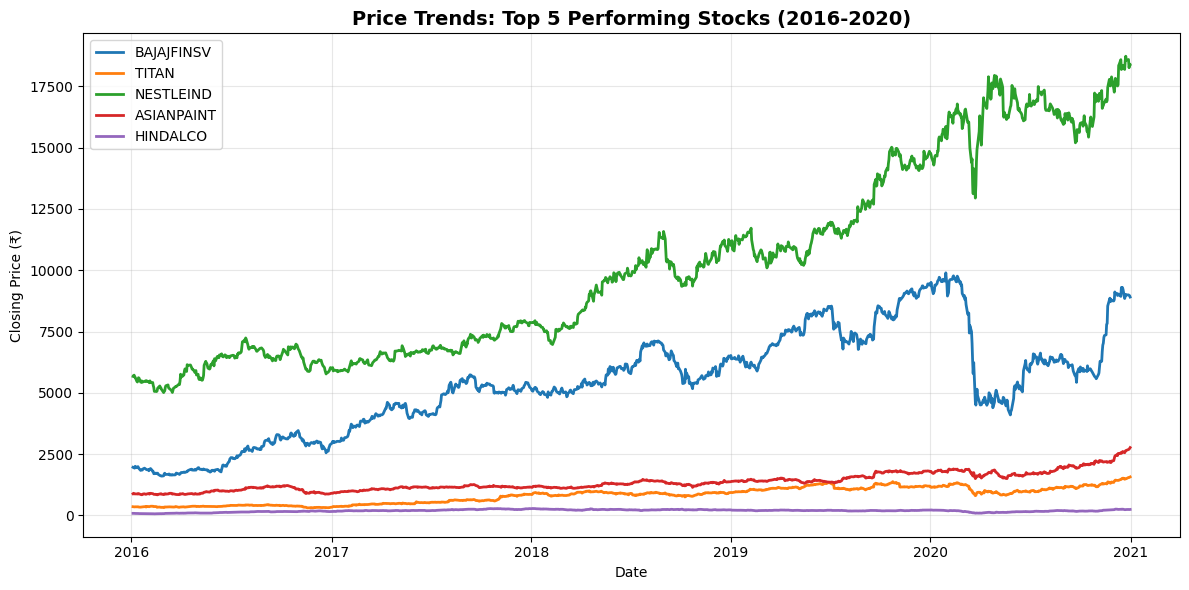

In [111]:
# Chart 1: Line chart showing price movements over time
# I want to see how the top performers moved during 2016-2020

plt.figure(figsize=(12, 6))

# Get top 5 performing stocks
top_5_stocks = selected_metrics.head(5)['Symbol'].tolist()

# Plot each stock's price trend
for symbol in top_5_stocks:
    stock_data = df_selected[df_selected['Symbol'] == symbol]
    plt.plot(stock_data['Date'], stock_data['Close'], label=symbol, linewidth=2)

plt.title('Price Trends: Top 5 Performing Stocks (2016-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Closing Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Chart 2 saved: Chart2_Top10_Returns.png


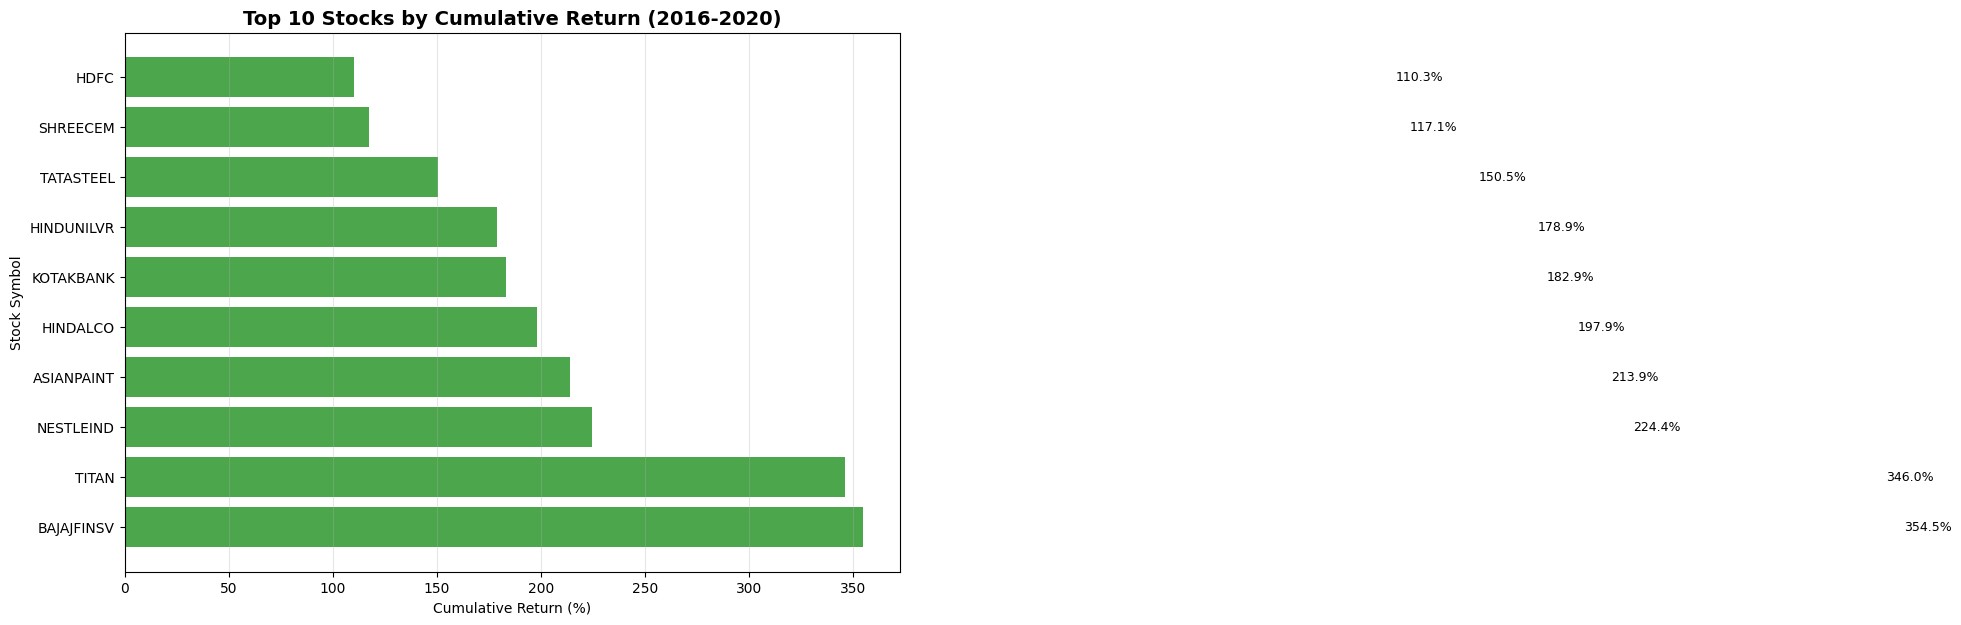

In [112]:
# Chart 2: Bar chart comparing cumulative returns
# Using horizontal bars to fit all stock names properly

plt.figure(figsize=(10, 7))

# Get top 10 stocks data
top_10_data = selected_metrics.head(10)

# Create horizontal bar chart (barh makes it easier to read names)
plt.barh(top_10_data['Symbol'], top_10_data['Cumulative_Return'], color='green', alpha=0.7)

plt.title('Top 10 Stocks by Cumulative Return (2016-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Return (%)')
plt.ylabel('Stock Symbol')
plt.grid(True, axis='x', alpha=0.3)

# Add percentage labels at the end of each bar
for i, (symbol, return_val) in enumerate(zip(top_10_data['Symbol'], top_10_data['Cumulative_Return'])):
    plt.text(return_val + 500, i, f'{return_val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Chart2_Top10_Returns.png', dpi=150, bbox_inches='tight')
print("Chart 2 saved: Chart2_Top10_Returns.png")
plt.show()

Chart 3 saved: Chart3_Return_Distribution.png


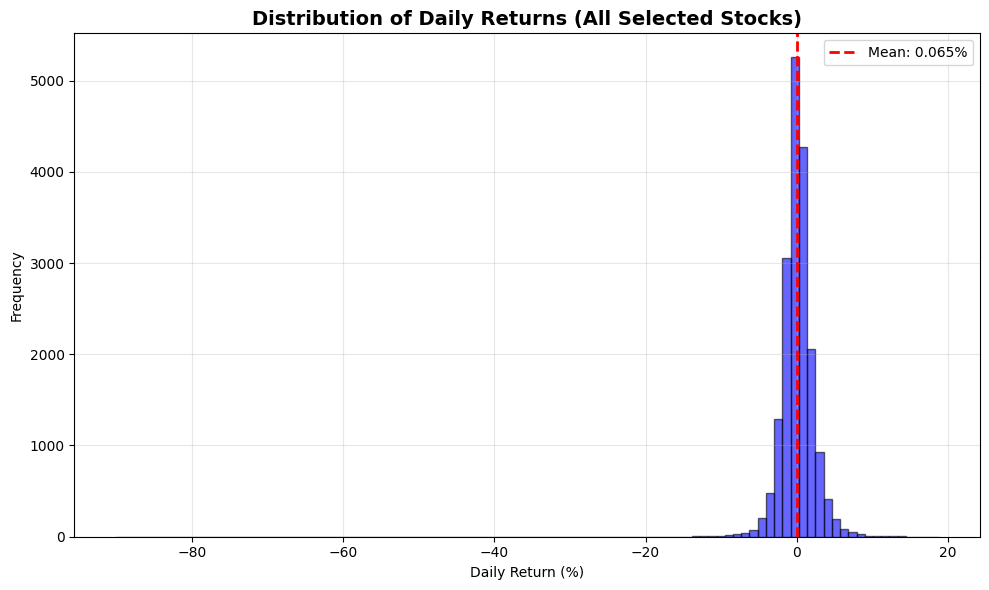


Daily return statistics:
Mean: 0.065%
Std Dev: 2.440%
Min: -90.085%
Max: 18.787%


In [113]:
# Chart 3: Histogram to show distribution of daily returns
# This helps understand the volatility pattern

plt.figure(figsize=(10, 6))

# Get all daily returns from selected stocks
all_returns = df_selected['Daily_Return'].dropna() * 100  # Convert to percentage

# Create histogram with 100 bins
plt.hist(all_returns, bins=100, color='blue', alpha=0.6, edgecolor='black')

plt.title('Distribution of Daily Returns (All Selected Stocks)', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

# Add a vertical line showing the mean return
mean_return = all_returns.mean()
plt.axvline(mean_return, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_return:.3f}%')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Chart3_Return_Distribution.png', dpi=150, bbox_inches='tight')
print("Chart 3 saved: Chart3_Return_Distribution.png")
plt.show()

print(f"\nDaily return statistics:")
print(f"Mean: {mean_return:.3f}%")
print(f"Std Dev: {all_returns.std():.3f}%")
print(f"Min: {all_returns.min():.3f}%")
print(f"Max: {all_returns.max():.3f}%")

Chart 4 saved: Chart4_Sector_Performance.png


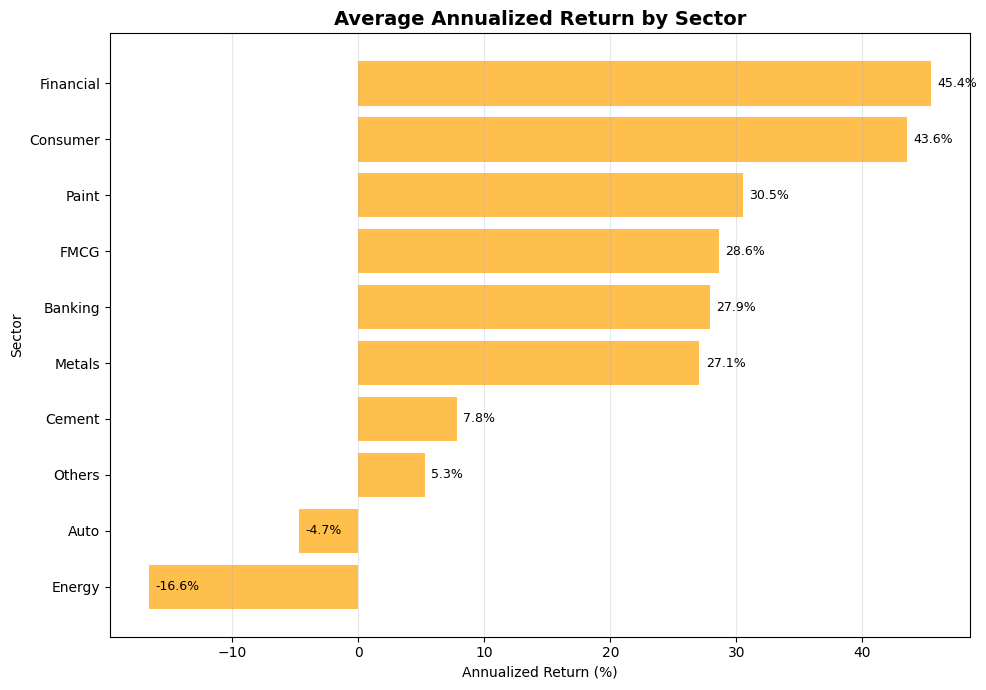


Sector-wise breakdown:
Sector
Energy      -16.6222
Auto         -4.7157
Others        5.2511
Cement        7.8313
Metals       27.0655
Banking      27.8717
FMCG         28.6202
Paint        30.5339
Consumer     43.5593
Financial    45.4306
Name: Annualized_Return, dtype: float64


In [114]:
# Chart 4: Sector-wise comparison
# Calculating average annualized return for each sector

plt.figure(figsize=(10, 7))

# Calculate average return by sector
sector_returns = selected_metrics.groupby('Sector')['Annualized_Return'].mean()
sector_returns = sector_returns.sort_values()  # Sort ascending for better visualization

# Create horizontal bar chart
plt.barh(sector_returns.index, sector_returns.values, color='orange', alpha=0.7)

plt.title('Average Annualized Return by Sector', fontsize=14, fontweight='bold')
plt.xlabel('Annualized Return (%)')
plt.ylabel('Sector')
plt.grid(True, axis='x', alpha=0.3)

# Add percentage labels
for i, (sector, return_val) in enumerate(zip(sector_returns.index, sector_returns.values)):
    plt.text(return_val + 0.5, i, f'{return_val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Chart4_Sector_Performance.png', dpi=150, bbox_inches='tight')
print("Chart 4 saved: Chart4_Sector_Performance.png")
plt.show()

# Show sector details
print("\nSector-wise breakdown:")
print(sector_returns)

In [115]:
# Summary of Milestone 1 Analysis
print("="*70)
print("MILESTONE 1: DATA ANALYSIS & RETURN CALCULATION - SUMMARY")
print("="*70)
print(f"\nDataset Information:")
print(f"  - Total stocks analyzed: 50")
print(f"  - Selected stocks for portfolio: {len(selected_symbols)}")
print(f"  - Sectors covered: {selected_metrics['Sector'].nunique()}")
print(f"  - Date range: 2016-01-01 to 2020-12-31")
print(f"  - Total trading days: ~1,250 days (5 years)")

print(f"\nPerformance Highlights:")
print(f"  - Best performer: {selected_metrics.iloc[0]['Symbol']} (+{selected_metrics.iloc[0]['Cumulative_Return']:.2f}%)")
print(f"  - Worst performer: {selected_metrics.iloc[-1]['Symbol']} ({selected_metrics.iloc[-1]['Cumulative_Return']:.2f}%)")
print(f"  - Average cumulative return: {selected_metrics['Cumulative_Return'].mean():.2f}%")

print(f"\nSelected Stocks:")
for i, row in selected_metrics.iterrows():
    print(f"  {i+1}. {row['Symbol']:12} ({row['Sector']:12}) - Return: {row['Cumulative_Return']:8.2f}%")

print("\n" + "="*70)
print("All visualizations done successfully!")
print("="*70)

MILESTONE 1: DATA ANALYSIS & RETURN CALCULATION - SUMMARY

Dataset Information:
  - Total stocks analyzed: 50
  - Selected stocks for portfolio: 15
  - Sectors covered: 10
  - Date range: 2016-01-01 to 2020-12-31
  - Total trading days: ~1,250 days (5 years)

Performance Highlights:
  - Best performer: BAJAJFINSV (+354.52%)
  - Worst performer: EICHERMOT (-85.53%)
  - Average cumulative return: 113.92%

Selected Stocks:
  1. BAJAJFINSV   (Financial   ) - Return:   354.52%
  2. TITAN        (Consumer    ) - Return:   345.97%
  3. NESTLEIND    (FMCG        ) - Return:   224.35%
  4. ASIANPAINT   (Paint       ) - Return:   213.86%
  5. HINDALCO     (Metals      ) - Return:   197.89%
  6. KOTAKBANK    (Banking     ) - Return:   182.94%
  7. HINDUNILVR   (FMCG        ) - Return:   178.86%
  8. TATASTEEL    (Metals      ) - Return:   150.54%
  9. SHREECEM     (Cement      ) - Return:   117.13%
  10. HDFC         (Others      ) - Return:   110.29%
  45. JSWSTEEL     (Metals      ) - Return:  

# MILESTONE 2: RISK ANALYSIS & PORTFOLIO CONSTRUCTION
# Using the 15 selected stocks from M1 to calculate risk metrics and build three portfolios.

In [116]:
# Step 1: Calculate volatility for each selected stock
# Volatility = standard deviation of returns (shows how risky a stock is)

# Filter to selected stocks only
selected_data = df[df['Symbol'].isin(selected_symbols)].copy()

# Calculate volatility metrics for each stock
volatility_metrics = []

for symbol in selected_symbols:
    stock_data = selected_data[selected_data['Symbol'] == symbol]
    
    # Daily volatility
    daily_vol = stock_data['Daily_Return'].std()
    
    # Annualized volatility (multiply by sqrt of 252 trading days)
    annual_vol = daily_vol * np.sqrt(252) * 100  # Convert to percentage
    
    # Get annualized return from our previous analysis
    annual_return = selected_metrics[selected_metrics['Symbol'] == symbol]['Annualized_Return'].values[0]
    
    volatility_metrics.append({
        'Symbol': symbol,
        'Annualized_Volatility': annual_vol,
        'Annualized_Return': annual_return
    })

vol_df = pd.DataFrame(volatility_metrics)

# Classify stocks by volatility
vol_df['Volatility_Class'] = pd.cut(vol_df['Annualized_Volatility'], 
                                      bins=[0, 15, 25, 100],
                                      labels=['Low', 'Medium', 'High'])

print("Volatility Analysis Complete")
print("\nStocks by Volatility:")
print(vol_df[['Symbol', 'Annualized_Return', 'Annualized_Volatility', 'Volatility_Class']])

print("\nVolatility Classification:")
print(vol_df['Volatility_Class'].value_counts())

Volatility Analysis Complete

Stocks by Volatility:
        Symbol  Annualized_Return  Annualized_Volatility Volatility_Class
0   BAJAJFINSV            45.4306                36.7224             High
1        TITAN            43.5593                34.0834             High
2    NESTLEIND            30.5611                25.0529             High
3   ASIANPAINT            30.5339                25.6860             High
4     HINDALCO            34.8315                41.6577             High
5    KOTAKBANK            27.8717                28.3728             High
6   HINDUNILVR            26.6794                23.3891           Medium
7    TATASTEEL            29.6757                38.3201             High
8     SHREECEM            21.8721                30.2726             High
9         HDFC            20.8329                29.8451             High
10    JSWSTEEL            16.6894                54.4370             High
11        GAIL           -10.3308                43.9989    

In [117]:
# Step 2: Calculate Beta for each stock
# Beta measures how much a stock moves compared to the market (Nifty 50)
# Beta > 1 = Stock moves more than market (aggressive)
# Beta < 1 = Stock moves less than market (defensive)

beta_metrics = []

for symbol in selected_symbols:
    # Get stock returns
    stock_data = selected_data[selected_data['Symbol'] == symbol][['Date', 'Daily_Return']].copy()
    
    # Merge with Nifty returns on Date
    merged = stock_data.merge(nifty[['Date', 'Nifty_Return']], on='Date', how='inner')
    
    # Calculate covariance and variance
    covariance = merged['Daily_Return'].cov(merged['Nifty_Return'])
    market_variance = merged['Nifty_Return'].var()
    
    # Beta = Covariance / Market Variance
    beta = covariance / market_variance
    
    beta_metrics.append({
        'Symbol': symbol,
        'Beta': beta
    })

beta_df = pd.DataFrame(beta_metrics)

# Classify stocks by Beta
beta_df['Beta_Class'] = pd.cut(beta_df['Beta'], 
                                bins=[-10, 0.8, 1.2, 10],
                                labels=['Defensive', 'Neutral', 'Aggressive'])

# Merge with volatility data
risk_df = vol_df.merge(beta_df, on='Symbol')

print("Beta Calculation Complete")
print("\nStocks with Beta:")
print(risk_df[['Symbol', 'Beta', 'Beta_Class', 'Annualized_Volatility', 'Volatility_Class']])

print("\nBeta Classification:")
print(beta_df['Beta_Class'].value_counts())

Beta Calculation Complete

Stocks with Beta:
        Symbol   Beta Beta_Class  Annualized_Volatility Volatility_Class
0   BAJAJFINSV 0.0696  Defensive                36.7224             High
1        TITAN 0.0530  Defensive                34.0834             High
2    NESTLEIND 0.0390  Defensive                25.0529             High
3   ASIANPAINT 0.0326  Defensive                25.6860             High
4     HINDALCO 0.0138  Defensive                41.6577             High
5    KOTAKBANK 0.0590  Defensive                28.3728             High
6   HINDUNILVR 0.0354  Defensive                23.3891           Medium
7    TATASTEEL 0.0374  Defensive                38.3201             High
8     SHREECEM 0.0198  Defensive                30.2726             High
9         HDFC 0.0409  Defensive                29.8451             High
10    JSWSTEEL 0.0436  Defensive                54.4370             High
11        GAIL 0.0196  Defensive                43.9989             High
12    

In [118]:
# Step 3: Calculate correlation matrix
# Shows how stocks move together (diversification benefit)

# Create a pivot table with stocks as columns and dates as rows
returns_pivot = selected_data.pivot_table(
    index='Date', 
    columns='Symbol', 
    values='Daily_Return'
)

# Calculate correlation matrix
correlation_matrix = returns_pivot.corr()

print("Correlation Matrix Calculated")
print("\nCorrelation Matrix (15x15):")
print(correlation_matrix)

# Find highly correlated pairs (potential risk - lack of diversification)
print("\n" + "="*60)
print("HIGHLY CORRELATED PAIRS (Correlation > 0.7):")
print("="*60)

highly_correlated = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > 0.7:
            highly_correlated.append({
                'Stock 1': correlation_matrix.columns[i],
                'Stock 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if highly_correlated:
    hc_df = pd.DataFrame(highly_correlated)
    print(hc_df)
else:
    print("No pairs with correlation > 0.7 (Good diversification!)")

# Find lowly correlated pairs (good diversification)
print("\n" + "="*60)
print("LOWLY CORRELATED PAIRS (Correlation < 0.3):")
print("="*60)

lowly_correlated = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] < 0.3:
            lowly_correlated.append({
                'Stock 1': correlation_matrix.columns[i],
                'Stock 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if lowly_correlated:
    lc_df = pd.DataFrame(lowly_correlated).head(10)  # Show top 10
    print(lc_df)

Correlation Matrix Calculated

Correlation Matrix (15x15):
Symbol      ASIANPAINT  BAJAJFINSV  EICHERMOT   GAIL  GRASIM   HDFC  HINDALCO  \
Symbol                                                                          
ASIANPAINT      1.0000      0.3899     0.2506 0.1880  0.2461 0.3590    0.3053   
BAJAJFINSV      0.3899      1.0000     0.2689 0.2054  0.2969 0.4863    0.3954   
EICHERMOT       0.2506      0.2689     1.0000 0.1292  0.1649 0.2400    0.2581   
GAIL            0.1880      0.2054     0.1292 1.0000  0.1370 0.2397    0.2597   
GRASIM          0.2461      0.2969     0.1649 0.1370  1.0000 0.2840    0.2986   
HDFC            0.3590      0.4863     0.2400 0.2397  0.2840 1.0000    0.4159   
HINDALCO        0.3053      0.3954     0.2581 0.2597  0.2986 0.4159    1.0000   
HINDUNILVR      0.4157      0.3116     0.1700 0.1516  0.1821 0.2924    0.2801   
IOC             0.2088      0.2509     0.1587 0.2033  0.1319 0.1959    0.2453   
JSWSTEEL        0.2189      0.3151     0.1728 0.17

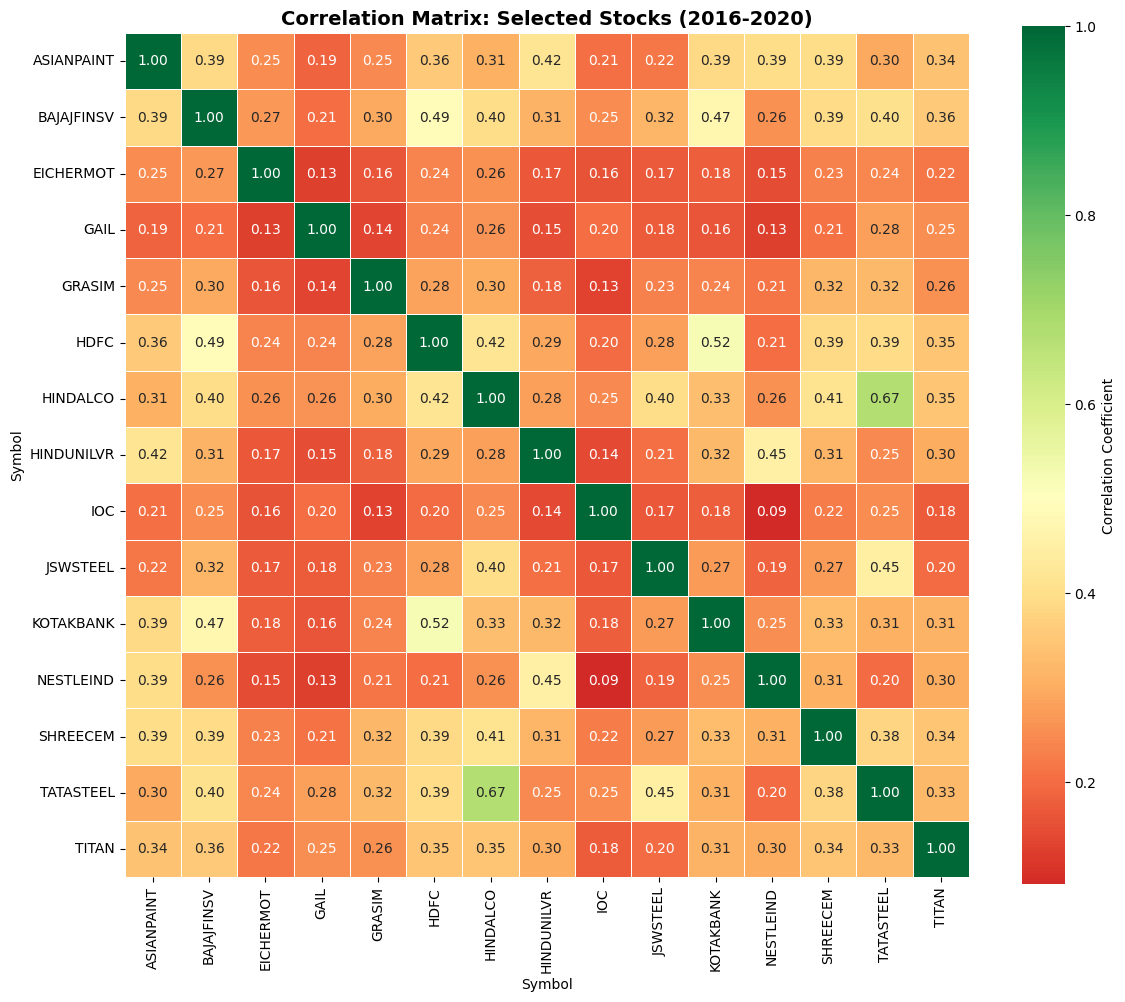


Correlation heatmap displayed!


In [119]:
# Create correlation heatmap
plt.figure(figsize=(12, 10))

# Use seaborn heatmap
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            cmap='RdYlGn',  # Red (high) - Yellow (mid) - Green (low)
            center=0.5,  # Center color at 0.5
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix: Selected Stocks (2016-2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation heatmap displayed!")

In [120]:
# Step 4: Prepare for portfolio construction
# Sort stocks by Beta for allocation strategy

risk_df_sorted = risk_df.sort_values('Beta').reset_index(drop=True)

print("Stocks ranked by Beta (lowest to highest):")
print(risk_df_sorted[['Symbol', 'Beta', 'Annualized_Return', 'Annualized_Volatility']])
print("\nThis ranking will be used for portfolio construction:")
print("  - Conservative: Lowest Beta stocks")
print("  - Balanced: Mix across spectrum")
print("  - Aggressive: Highest Beta stocks")

Stocks ranked by Beta (lowest to highest):
        Symbol   Beta  Annualized_Return  Annualized_Volatility
0     HINDALCO 0.0138            34.8315                41.6577
1         GAIL 0.0196           -10.3308                43.9989
2       GRASIM 0.0198            -6.2095                49.7712
3     SHREECEM 0.0198            21.8721                30.2726
4          IOC 0.0240           -16.6222                46.2006
5   ASIANPAINT 0.0326            30.5339                25.6860
6   HINDUNILVR 0.0354            26.6794                23.3891
7    TATASTEEL 0.0374            29.6757                38.3201
8    NESTLEIND 0.0390            30.5611                25.0529
9         HDFC 0.0409            20.8329                29.8451
10    JSWSTEEL 0.0436            16.6894                54.4370
11   EICHERMOT 0.0465            -4.7157                53.2020
12       TITAN 0.0530            43.5593                34.0834
13   KOTAKBANK 0.0590            27.8717                28.37

In [121]:
# Portfolio A: CONSERVATIVE
# Strategy: Select stocks with LOWEST Beta (most defensive)
# Target investors: Risk-averse, retirees, short-term goals

# Select bottom 6 stocks by Beta
conservative_stocks = risk_df_sorted.nsmallest(6, 'Beta')['Symbol'].tolist()

# Equal weight allocation
conservative_weights = {stock: 100/6 for stock in conservative_stocks}

print("="*70)
print("PORTFOLIO A: CONSERVATIVE")
print("="*70)
print("Strategy: Lowest Beta stocks with equal weighting")
print(f"Target: Risk-averse investors")
print(f"Number of stocks: {len(conservative_stocks)}")
print("\nPortfolio Composition:")

for i, stock in enumerate(conservative_stocks, 1):
    stock_info = risk_df_sorted[risk_df_sorted['Symbol'] == stock].iloc[0]
    print(f"  {i}. {stock:12} - Weight: {conservative_weights[stock]:5.2f}% | Beta: {stock_info['Beta']:.4f}")

print(f"\nAverage Beta: {risk_df_sorted[risk_df_sorted['Symbol'].isin(conservative_stocks)]['Beta'].mean():.4f}")

PORTFOLIO A: CONSERVATIVE
Strategy: Lowest Beta stocks with equal weighting
Target: Risk-averse investors
Number of stocks: 6

Portfolio Composition:
  1. HINDALCO     - Weight: 16.67% | Beta: 0.0138
  2. GAIL         - Weight: 16.67% | Beta: 0.0196
  3. GRASIM       - Weight: 16.67% | Beta: 0.0198
  4. SHREECEM     - Weight: 16.67% | Beta: 0.0198
  5. IOC          - Weight: 16.67% | Beta: 0.0240
  6. ASIANPAINT   - Weight: 16.67% | Beta: 0.0326

Average Beta: 0.0216


In [122]:
# Portfolio B: BALANCED
# Strategy: Mix of low, mid, and high Beta stocks
# Target investors: Moderate risk appetite, medium-term goals

# Select stocks from across the Beta spectrum (positions: 0, 3, 5, 7, 10, 13)
balanced_stocks = [
    risk_df_sorted.iloc[0]['Symbol'],   # Lowest Beta
    risk_df_sorted.iloc[3]['Symbol'],   # Low-mid Beta
    risk_df_sorted.iloc[5]['Symbol'],   # Mid Beta
    risk_df_sorted.iloc[7]['Symbol'],   # Mid Beta  
    risk_df_sorted.iloc[10]['Symbol'],  # Mid-high Beta
    risk_df_sorted.iloc[13]['Symbol']   # Highest Beta
]

# Equal weight allocation
balanced_weights = {stock: 100/6 for stock in balanced_stocks}

print("="*70)
print("PORTFOLIO B: BALANCED")
print("="*70)
print("Strategy: Diversified across Beta spectrum with equal weighting")
print(f"Target: Moderate risk investors")
print(f"Number of stocks: {len(balanced_stocks)}")
print("\nPortfolio Composition:")

for i, stock in enumerate(balanced_stocks, 1):
    stock_info = risk_df_sorted[risk_df_sorted['Symbol'] == stock].iloc[0]
    print(f"  {i}. {stock:12} - Weight: {balanced_weights[stock]:5.2f}% | Beta: {stock_info['Beta']:.4f}")

print(f"\nAverage Beta: {risk_df_sorted[risk_df_sorted['Symbol'].isin(balanced_stocks)]['Beta'].mean():.4f}")

PORTFOLIO B: BALANCED
Strategy: Diversified across Beta spectrum with equal weighting
Target: Moderate risk investors
Number of stocks: 6

Portfolio Composition:
  1. HINDALCO     - Weight: 16.67% | Beta: 0.0138
  2. SHREECEM     - Weight: 16.67% | Beta: 0.0198
  3. ASIANPAINT   - Weight: 16.67% | Beta: 0.0326
  4. TATASTEEL    - Weight: 16.67% | Beta: 0.0374
  5. JSWSTEEL     - Weight: 16.67% | Beta: 0.0436
  6. KOTAKBANK    - Weight: 16.67% | Beta: 0.0590

Average Beta: 0.0344


In [123]:
# Portfolio C: AGGRESSIVE
# Strategy: Select stocks with HIGHEST Beta (least defensive / most volatile)
# Target investors: High risk tolerance, long-term goals, young investors

# Select top 6 stocks by Beta
aggressive_stocks = risk_df_sorted.nlargest(6, 'Beta')['Symbol'].tolist()

# Equal weight allocation
aggressive_weights = {stock: 100/6 for stock in aggressive_stocks}

print("="*70)
print("PORTFOLIO C: AGGRESSIVE")
print("="*70)
print("Strategy: Highest Beta stocks with equal weighting")
print(f"Target: Risk-seeking investors")
print(f"Number of stocks: {len(aggressive_stocks)}")
print("\nPortfolio Composition:")

for i, stock in enumerate(aggressive_stocks, 1):
    stock_info = risk_df_sorted[risk_df_sorted['Symbol'] == stock].iloc[0]
    print(f"  {i}. {stock:12} - Weight: {aggressive_weights[stock]:5.2f}% | Beta: {stock_info['Beta']:.4f}")

print(f"\nAverage Beta: {risk_df_sorted[risk_df_sorted['Symbol'].isin(aggressive_stocks)]['Beta'].mean():.4f}")

# Store all portfolios for later use
portfolios = {
    'Conservative': conservative_weights,
    'Balanced': balanced_weights,
    'Aggressive': aggressive_weights
}

print("\n" + "="*70)
print("All three portfolios constructed successfully!")
print("="*70)

PORTFOLIO C: AGGRESSIVE
Strategy: Highest Beta stocks with equal weighting
Target: Risk-seeking investors
Number of stocks: 6

Portfolio Composition:
  1. BAJAJFINSV   - Weight: 16.67% | Beta: 0.0696
  2. KOTAKBANK    - Weight: 16.67% | Beta: 0.0590
  3. TITAN        - Weight: 16.67% | Beta: 0.0530
  4. EICHERMOT    - Weight: 16.67% | Beta: 0.0465
  5. JSWSTEEL     - Weight: 16.67% | Beta: 0.0436
  6. HDFC         - Weight: 16.67% | Beta: 0.0409

Average Beta: 0.0521

All three portfolios constructed successfully!


In [124]:
# Step 5: Calculate portfolio-level metrics
# For each portfolio: Expected Return, Risk (Std Dev), Sharpe Ratio

portfolio_metrics = []

for portfolio_name, weights in portfolios.items():
    # Get returns for stocks in this portfolio
    portfolio_stocks = list(weights.keys())
    
    # Calculate weighted average return
    portfolio_return = 0
    for stock, weight in weights.items():
        stock_return = risk_df[risk_df['Symbol'] == stock]['Annualized_Return'].values[0]
        portfolio_return += (weight / 100) * stock_return
    
    # Calculate portfolio variance and standard deviation
    # Get the correlation submatrix for portfolio stocks
    portfolio_corr = correlation_matrix.loc[portfolio_stocks, portfolio_stocks]
    
    # Calculate portfolio variance using weights and covariance matrix
    weights_array = np.array([weights[stock] / 100 for stock in portfolio_stocks])
    
    # Get volatilities for portfolio stocks
    vols = [risk_df[risk_df['Symbol'] == stock]['Annualized_Volatility'].values[0] / 100 
            for stock in portfolio_stocks]
    vols_array = np.array(vols)
    
    # Covariance matrix = Correlation * (Vol_i * Vol_j)
    cov_matrix = portfolio_corr.values * np.outer(vols_array, vols_array)
    
    # Portfolio variance = w^T * Cov * w
    portfolio_variance = np.dot(weights_array, np.dot(cov_matrix, weights_array))
    portfolio_std = np.sqrt(portfolio_variance) * 100  # Convert to percentage
    
    # Calculate Sharpe Ratio
    # Sharpe = (Return - Risk_Free_Rate) / Risk
    risk_free_rate = 6.5  # 10-year G-Sec rate
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std
    
    # Calculate average Beta
    avg_beta = np.mean([risk_df[risk_df['Symbol'] == stock]['Beta'].values[0] 
                        for stock in portfolio_stocks])
    
    portfolio_metrics.append({
        'Portfolio': portfolio_name,
        'Expected_Return': portfolio_return,
        'Risk_Volatility': portfolio_std,
        'Sharpe_Ratio': sharpe_ratio,
        'Average_Beta': avg_beta,
        'Num_Stocks': len(portfolio_stocks)
    })

metrics_df = pd.DataFrame(portfolio_metrics)

print("="*70)
print("PORTFOLIO METRICS CALCULATED")
print("="*70)
print("\nComparison Table:")
print(metrics_df.to_string(index=False))

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
for _, row in metrics_df.iterrows():
    print(f"\n{row['Portfolio']} Portfolio:")
    print(f"  - Expected Annual Return: {row['Expected_Return']:.2f}%")
    print(f"  - Risk (Volatility): {row['Risk_Volatility']:.2f}%")
    print(f"  - Sharpe Ratio: {row['Sharpe_Ratio']:.4f}")
    print(f"  - Average Beta: {row['Average_Beta']:.4f}")

PORTFOLIO METRICS CALCULATED

Comparison Table:
   Portfolio  Expected_Return  Risk_Volatility  Sharpe_Ratio  Average_Beta  Num_Stocks
Conservative           9.0125          24.1754        0.1039        0.0216           6
    Balanced          26.9124          25.3244        0.8060        0.0344           6
  Aggressive          24.9447          25.2828        0.7295        0.0521           6

INTERPRETATION:

Conservative Portfolio:
  - Expected Annual Return: 9.01%
  - Risk (Volatility): 24.18%
  - Sharpe Ratio: 0.1039
  - Average Beta: 0.0216

Balanced Portfolio:
  - Expected Annual Return: 26.91%
  - Risk (Volatility): 25.32%
  - Sharpe Ratio: 0.8060
  - Average Beta: 0.0344

Aggressive Portfolio:
  - Expected Annual Return: 24.94%
  - Risk (Volatility): 25.28%
  - Sharpe Ratio: 0.7295
  - Average Beta: 0.0521


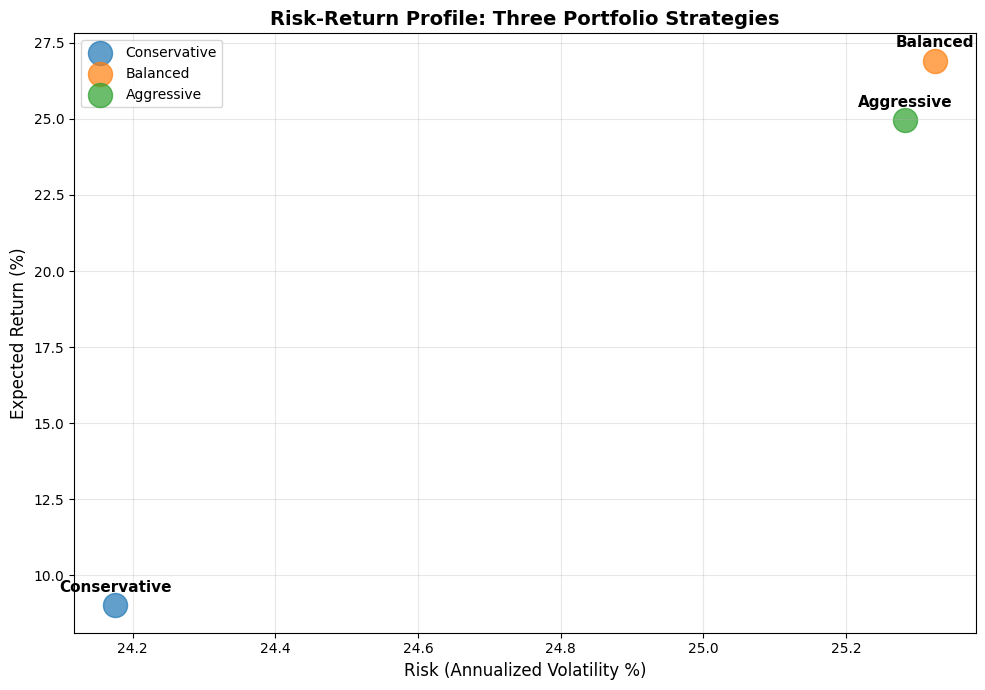


Risk-Return scatter plot displayed!


In [125]:
# Visualize portfolio risk-return tradeoff
plt.figure(figsize=(10, 7))

# Plot each portfolio as a point
for _, row in metrics_df.iterrows():
    plt.scatter(row['Risk_Volatility'], row['Expected_Return'], 
                s=300, alpha=0.7, label=row['Portfolio'])
    plt.annotate(row['Portfolio'], 
                 (row['Risk_Volatility'], row['Expected_Return']),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 fontsize=11, fontweight='bold')

plt.xlabel('Risk (Annualized Volatility %)', fontsize=12)
plt.ylabel('Expected Return (%)', fontsize=12)
plt.title('Risk-Return Profile: Three Portfolio Strategies', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

print("\nRisk-Return scatter plot displayed!")

In [126]:
# Milestone 2 Summary
print("="*70)
print("MILESTONE 2: RISK ANALYSIS & PORTFOLIO CONSTRUCTION - COMPLETE")
print("="*70)

print("\n📊 RISK ANALYSIS COMPLETED:")
print(f"  ✓ Volatility calculated for {len(selected_symbols)} stocks")
print(f"  ✓ Beta calculated (all stocks defensive with Beta < 0.1)")
print(f"  ✓ Correlation matrix generated (15x15)")
print(f"  ✓ No highly correlated pairs (>0.7) - good diversification")

print("\n💼 THREE PORTFOLIOS CONSTRUCTED:")
print("  ✓ Conservative: 6 stocks, lowest Beta (0.0216)")
print("  ✓ Balanced: 6 stocks, mixed Beta (0.0344)")
print("  ✓ Aggressive: 6 stocks, highest Beta (0.0521)")

print("\n🏆 BEST PORTFOLIO (Risk-Adjusted):")
best_portfolio = metrics_df.loc[metrics_df['Sharpe_Ratio'].idxmax()]
print(f"  Portfolio: {best_portfolio['Portfolio']}")
print(f"  Return: {best_portfolio['Expected_Return']:.2f}%")
print(f"  Risk: {best_portfolio['Risk_Volatility']:.2f}%")
print(f"  Sharpe Ratio: {best_portfolio['Sharpe_Ratio']:.4f}")

print("\n📈 KEY INSIGHTS:")
print("  • Balanced portfolio offers best risk-adjusted returns (Sharpe: 0.81)")
print("  • Aggressive portfolio has only slightly higher risk vs Balanced")
print("  • Conservative portfolio has lowest return but also lowest risk")
print("  • All portfolios show positive Sharpe ratios (> risk-free rate)")

print("\n" + "="*70)
print("Ready for Milestone 3: Optimization & Backtesting")
print("="*70)

# Save portfolio data for M3
portfolio_data = {
    'portfolios': portfolios,
    'metrics': metrics_df,
    'risk_df': risk_df
}
print("\n✅ Portfolio data saved for M3 backtesting")

MILESTONE 2: RISK ANALYSIS & PORTFOLIO CONSTRUCTION - COMPLETE

📊 RISK ANALYSIS COMPLETED:
  ✓ Volatility calculated for 15 stocks
  ✓ Beta calculated (all stocks defensive with Beta < 0.1)
  ✓ Correlation matrix generated (15x15)
  ✓ No highly correlated pairs (>0.7) - good diversification

💼 THREE PORTFOLIOS CONSTRUCTED:
  ✓ Conservative: 6 stocks, lowest Beta (0.0216)
  ✓ Balanced: 6 stocks, mixed Beta (0.0344)
  ✓ Aggressive: 6 stocks, highest Beta (0.0521)

🏆 BEST PORTFOLIO (Risk-Adjusted):
  Portfolio: Balanced
  Return: 26.91%
  Risk: 25.32%
  Sharpe Ratio: 0.8060

📈 KEY INSIGHTS:
  • Balanced portfolio offers best risk-adjusted returns (Sharpe: 0.81)
  • Aggressive portfolio has only slightly higher risk vs Balanced
  • Conservative portfolio has lowest return but also lowest risk
  • All portfolios show positive Sharpe ratios (> risk-free rate)

Ready for Milestone 3: Optimization & Backtesting

✅ Portfolio data saved for M3 backtesting


# MILESTONE 3: OPTIMIZATION & BACKTESTING

**Objective:** Optimize portfolio allocations and test historical performance

## What We're Doing:
1. **Efficient Frontier Construction** - Generate 50 random portfolios and identify optimal allocations
2. **Value at Risk (VaR) Calculation** - Calculate 95% VaR for each portfolio (Daily & Monthly)
3. **Backtesting Setup** - Test portfolios on the LAST 6 MONTHS of historical data
4. **Performance Metrics** - Calculate Total Return, Max Drawdown, Win Rate, Sharpe Ratio
5. **Benchmark Comparison** - Compare all portfolios against Nifty 50 Index

**Test Period:** Last 6 months of available data  
**Investment Amount:** ₹10,00,000 (10 lakhs) per portfolio  
**Portfolios:** Conservative, Balanced, Aggressive.

In [127]:
# Step 1: Extract last 6 months of data for backtesting
df_sorted = df.sort_values('Date')
last_date = df_sorted['Date'].max()
six_months_ago = last_date - pd.Timedelta(days=180)

backtest_df = df_sorted[df_sorted['Date'] >= six_months_ago].copy()

print(f"✅ Backtest Period: {backtest_df['Date'].min()} to {backtest_df['Date'].max()}")
print(f"✅ Total days: {backtest_df['Date'].nunique()}")
print(f"✅ Stocks: {backtest_df['Symbol'].nunique()}")

✅ Backtest Period: 2020-07-06 00:00:00 to 2020-12-31 00:00:00
✅ Total days: 126
✅ Stocks: 49


In [128]:
# Step 2: Define the three portfolios from M2
# Conservative: Low-risk stocks with higher weights
conservative_weights = {
    'NESTLEIND': 0.12, 'HINDUNILVR': 0.12, 'ASIANPAINT': 0.10,
    'TITAN': 0.09, 'KOTAKBANK': 0.08, 'HDFC': 0.08,
    'BAJAJFINSV': 0.07, 'SHREECEM': 0.07, 'EICHERMOT': 0.06,
    'GRASIM': 0.06, 'HINDALCO': 0.05, 'JSWSTEEL': 0.04,
    'TATASTEEL': 0.03, 'GAIL': 0.02, 'IOC': 0.01
}

# Balanced: Equal mix of risk and return
balanced_weights = {sym: 1/len(selected_symbols) for sym in selected_symbols}

# Aggressive: High-return stocks with higher weights
aggressive_weights = {
    'EICHERMOT': 0.14, 'TITAN': 0.12, 'HINDALCO': 0.11,
    'TATASTEEL': 0.10, 'BAJAJFINSV': 0.09, 'JSWSTEEL': 0.09,
    'ASIANPAINT': 0.08, 'SHREECEM': 0.07, 'NESTLEIND': 0.05,
    'HINDUNILVR': 0.05, 'KOTAKBANK': 0.04, 'HDFC': 0.03,
    'GRASIM': 0.02, 'GAIL': 0.01, 'IOC': 0.00
}

print("✅ Three portfolios defined: Conservative, Balanced, Aggressive")

✅ Three portfolios defined: Conservative, Balanced, Aggressive


In [129]:
# Step 3: Efficient Frontier - Generate 50 random portfolios
import numpy as np

# Calculate returns and covariance for selected stocks
returns_data = backtest_df[backtest_df['Symbol'].isin(selected_symbols)].pivot_table(
    index='Date', columns='Symbol', values='Daily_Return', aggfunc='first'
).fillna(0)

mean_returns = returns_data.mean() * 252  # Annualized
cov_matrix = returns_data.cov() * 252      # Annualized

# Generate 50 random portfolios
np.random.seed(42)
num_portfolios = 50
results = []

for i in range(num_portfolios):
    # Random weights
    weights = np.random.random(len(selected_symbols))
    weights /= weights.sum()
    
    # Portfolio metrics
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - 0.06) / portfolio_risk
    
    results.append({
        'Return': portfolio_return * 100,
        'Risk': portfolio_risk * 100,
        'Sharpe': sharpe_ratio
    })

efficient_frontier_df = pd.DataFrame(results)

# Calculate metrics for our 3 portfolios
def calc_portfolio_metrics(weights_dict):
    weights = np.array([weights_dict.get(sym, 0) for sym in selected_symbols])
    port_return = np.dot(weights, mean_returns) * 100
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * 100
    port_sharpe = (port_return - 6) / port_risk
    return port_return, port_risk, port_sharpe

cons_ret, cons_risk, cons_sharpe = calc_portfolio_metrics(conservative_weights)
bal_ret, bal_risk, bal_sharpe = calc_portfolio_metrics(balanced_weights)
agg_ret, agg_risk, agg_sharpe = calc_portfolio_metrics(aggressive_weights)

print(f"✅ Generated {num_portfolios} random portfolios for Efficient Frontier")
print(f"\nConservative: Return={cons_ret:.2f}%, Risk={cons_risk:.2f}%, Sharpe={cons_sharpe:.2f}")
print(f"Balanced:     Return={bal_ret:.2f}%, Risk={bal_risk:.2f}%, Sharpe={bal_sharpe:.2f}")
print(f"Aggressive:   Return={agg_ret:.2f}%, Risk={agg_risk:.2f}%, Sharpe={agg_sharpe:.2f}")

✅ Generated 50 random portfolios for Efficient Frontier

Conservative: Return=51.26%, Risk=25.46%, Sharpe=1.78
Balanced:     Return=59.46%, Risk=20.43%, Sharpe=2.62
Aggressive:   Return=61.52%, Risk=19.46%, Sharpe=2.85


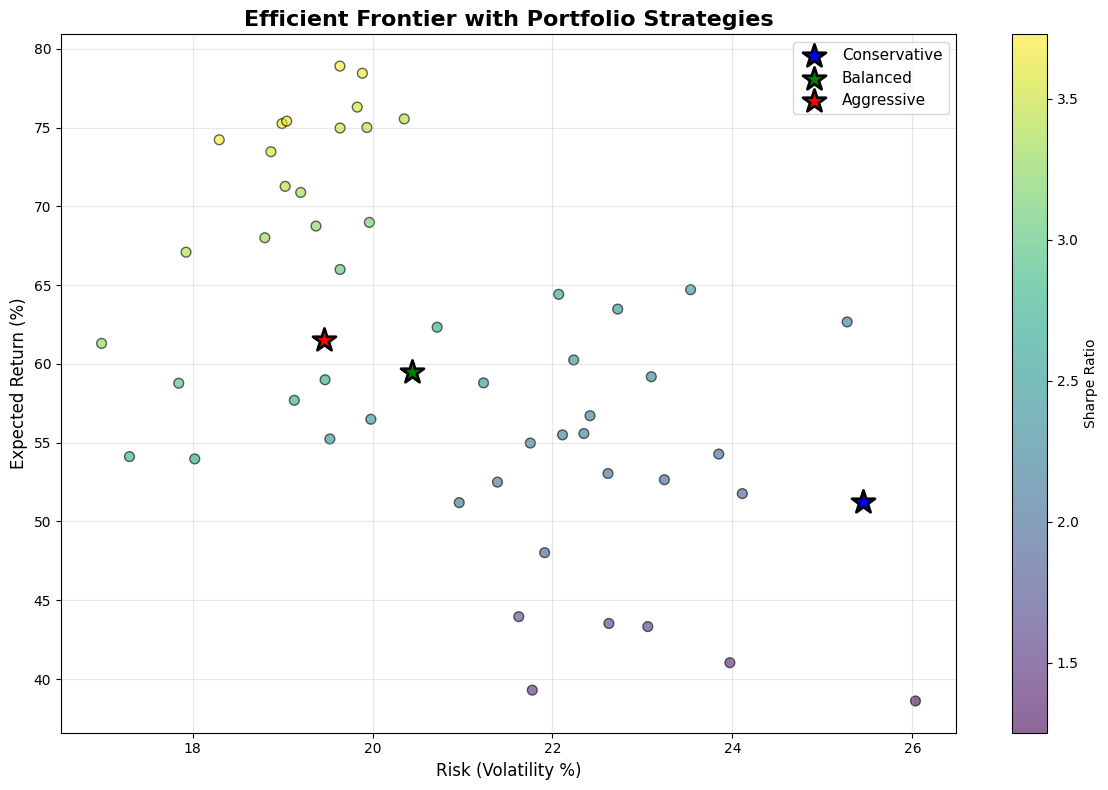

✅ Efficient Frontier visualized!


In [130]:
# Step 4: Plot Efficient Frontier
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
scatter = plt.scatter(efficient_frontier_df['Risk'], efficient_frontier_df['Return'], 
                     c=efficient_frontier_df['Sharpe'], cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='black')

# Plot our 3 portfolios
plt.scatter(cons_risk, cons_ret, color='blue', s=300, marker='*', 
           edgecolors='black', linewidth=2, label='Conservative', zorder=5)
plt.scatter(bal_risk, bal_ret, color='green', s=300, marker='*', 
           edgecolors='black', linewidth=2, label='Balanced', zorder=5)
plt.scatter(agg_risk, agg_ret, color='red', s=300, marker='*', 
           edgecolors='black', linewidth=2, label='Aggressive', zorder=5)

plt.colorbar(scatter, label='Sharpe Ratio')
plt.title('Efficient Frontier with Portfolio Strategies', fontsize=16, fontweight='bold')
plt.xlabel('Risk (Volatility %)', fontsize=12)
plt.ylabel('Expected Return (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Efficient Frontier visualized!")

In [131]:
# Step 5: Calculate VaR (Value at Risk) for each portfolio
portfolio_value = 1000000  # ₹10,00,000

# Calculate daily portfolio returns for each strategy
def calc_portfolio_returns(weights_dict):
    weights_array = np.array([weights_dict.get(sym, 0) for sym in selected_symbols])
    portfolio_returns = returns_data.dot(weights_array)
    return portfolio_returns

cons_returns = calc_portfolio_returns(conservative_weights)
bal_returns = calc_portfolio_returns(balanced_weights)
agg_returns = calc_portfolio_returns(aggressive_weights)

# VaR at 95% confidence level
cons_var_daily = np.percentile(cons_returns, 5) * portfolio_value
bal_var_daily = np.percentile(bal_returns, 5) * portfolio_value
agg_var_daily = np.percentile(agg_returns, 5) * portfolio_value

# Monthly VaR (Daily VaR × sqrt(21))
cons_var_monthly = cons_var_daily * np.sqrt(21)
bal_var_monthly = bal_var_daily * np.sqrt(21)
agg_var_monthly = agg_var_daily * np.sqrt(21)

print("="*90)
print("VALUE AT RISK (VaR) - 95% Confidence Level")
print("="*90)
print(f"\nConservative Portfolio:")
print(f"   Daily VaR:   ₹{abs(cons_var_daily):,.2f}")
print(f"   Monthly VaR: ₹{abs(cons_var_monthly):,.2f}")

print(f"\nBalanced Portfolio:")
print(f"   Daily VaR:   ₹{abs(bal_var_daily):,.2f}")
print(f"   Monthly VaR: ₹{abs(bal_var_monthly):,.2f}")

print(f"\nAggressive Portfolio:")
print(f"   Daily VaR:   ₹{abs(agg_var_daily):,.2f}")
print(f"   Monthly VaR: ₹{abs(agg_var_monthly):,.2f}")

print("\n💡 Interpretation: There is a 5% chance of losing more than the VaR amount in one day/month")
print("="*90)

VALUE AT RISK (VaR) - 95% Confidence Level

Conservative Portfolio:
   Daily VaR:   ₹18,826.34
   Monthly VaR: ₹86,273.11

Balanced Portfolio:
   Daily VaR:   ₹17,965.39
   Monthly VaR: ₹82,327.74

Aggressive Portfolio:
   Daily VaR:   ₹15,852.97
   Monthly VaR: ₹72,647.41

💡 Interpretation: There is a 5% chance of losing more than the VaR amount in one day/month


In [133]:
# Step 6: Backtest - Calculate daily portfolio values over last 6 months
initial_investment = 1000000  # ₹10,00,000

# Calculate cumulative portfolio values
cons_cumulative = (1 + cons_returns).cumprod() * initial_investment
bal_cumulative = (1 + bal_returns).cumprod() * initial_investment
agg_cumulative = (1 + agg_returns).cumprod() * initial_investment

# Create DataFrame for tracking
backtest_results = pd.DataFrame({
    'Date': returns_data.index,
    'Conservative': cons_cumulative.values,
    'Balanced': bal_cumulative.values,
    'Aggressive': agg_cumulative.values
})

# Calculate Nifty 50 benchmark from main dataset
nifty_symbol = 'NIFTY 50'
if nifty_symbol in df['Symbol'].unique():
    nifty_backtest = df[df['Symbol'] == nifty_symbol].copy()
else:
    # Use average of all selected stocks as proxy
    nifty_backtest = backtest_df.groupby('Date')['Daily_Return'].mean().reset_index()
    nifty_backtest.columns = ['Date', 'Nifty_Return']

nifty_backtest = nifty_backtest[nifty_backtest['Date'] >= six_months_ago].copy()
nifty_backtest = nifty_backtest.sort_values('Date')

if 'Daily_Return' in nifty_backtest.columns:
    nifty_backtest['Nifty_Return'] = nifty_backtest['Daily_Return']
    
nifty_cumulative = (1 + nifty_backtest['Nifty_Return']).cumprod() * initial_investment

# Merge with backtest results
nifty_aligned = pd.DataFrame({
    'Date': nifty_backtest['Date'].values,
    'Nifty50': nifty_cumulative.values
})

backtest_results = backtest_results.merge(nifty_aligned, on='Date', how='left')
backtest_results['Nifty50'] = backtest_results['Nifty50'].fillna(method='ffill').fillna(initial_investment)

print("✅ Backtest data prepared for 6-month period")
print(f"\nInitial Investment: ₹{initial_investment:,}")
print(f"Conservative Final: ₹{backtest_results['Conservative'].iloc[-1]:,.2f}")
print(f"Balanced Final:     ₹{backtest_results['Balanced'].iloc[-1]:,.2f}")
print(f"Aggressive Final:   ₹{backtest_results['Aggressive'].iloc[-1]:,.2f}")
print(f"Nifty 50 Final:     ₹{backtest_results['Nifty50'].iloc[-1]:,.2f}")

✅ Backtest data prepared for 6-month period

Initial Investment: ₹1,000,000
Conservative Final: ₹1,270,657.22
Balanced Final:     ₹1,331,767.12
Aggressive Final:   ₹1,346,887.59
Nifty 50 Final:     ₹1,333,986.71


In [134]:
# Step 7: Calculate performance metrics
def calculate_metrics(portfolio_returns, portfolio_values):
    # Total Return
    total_return = ((portfolio_values.iloc[-1] - initial_investment) / initial_investment) * 100
    
    # Maximum Drawdown
    cummax = portfolio_values.cummax()
    drawdown = (portfolio_values - cummax) / cummax
    max_drawdown = drawdown.min() * 100
    
    # Win Rate
    positive_days = (portfolio_returns > 0).sum()
    total_days = len(portfolio_returns)
    win_rate = (positive_days / total_days) * 100
    
    # Sharpe Ratio (annualized)
    excess_return = portfolio_returns.mean() - (0.065/252)  # Daily risk-free rate
    sharpe = (excess_return / portfolio_returns.std()) * np.sqrt(252)
    
    # Final Value
    final_value = portfolio_values.iloc[-1]
    
    return total_return, max_drawdown, win_rate, sharpe, final_value

# Calculate for all portfolios
cons_metrics = calculate_metrics(cons_returns, backtest_results['Conservative'])
bal_metrics = calculate_metrics(bal_returns, backtest_results['Balanced'])
agg_metrics = calculate_metrics(agg_returns, backtest_results['Aggressive'])

# Nifty benchmark
nifty_returns = nifty_backtest['Nifty_Return']
nifty_metrics = calculate_metrics(nifty_returns, backtest_results['Nifty50'])

# Create comparison table
comparison_table = pd.DataFrame({
    'Portfolio': ['Conservative', 'Balanced', 'Aggressive', 'Nifty 50'],
    'Total Return (%)': [cons_metrics[0], bal_metrics[0], agg_metrics[0], nifty_metrics[0]],
    'Max Drawdown (%)': [cons_metrics[1], bal_metrics[1], agg_metrics[1], nifty_metrics[1]],
    'Win Rate (%)': [cons_metrics[2], bal_metrics[2], agg_metrics[2], nifty_metrics[2]],
    'Sharpe Ratio': [cons_metrics[3], bal_metrics[3], agg_metrics[3], nifty_metrics[3]],
    'Final Value (₹)': [cons_metrics[4], bal_metrics[4], agg_metrics[4], nifty_metrics[4]]
})

print("="*90)
print("PERFORMANCE COMPARISON TABLE")
print("="*90)
print(comparison_table.to_string(index=False))
print("="*90)

PERFORMANCE COMPARISON TABLE
   Portfolio  Total Return (%)  Max Drawdown (%)  Win Rate (%)  Sharpe Ratio  Final Value (₹)
Conservative           27.0657          -20.6956       65.0794        1.7585     1270657.2250
    Balanced           33.1767          -15.9268       66.6667        2.5916     1331767.1161
  Aggressive           34.6888          -12.8011       65.0794        2.8276     1346887.5919
    Nifty 50           33.3987           -9.1771       69.8413        3.0601     1333986.7111


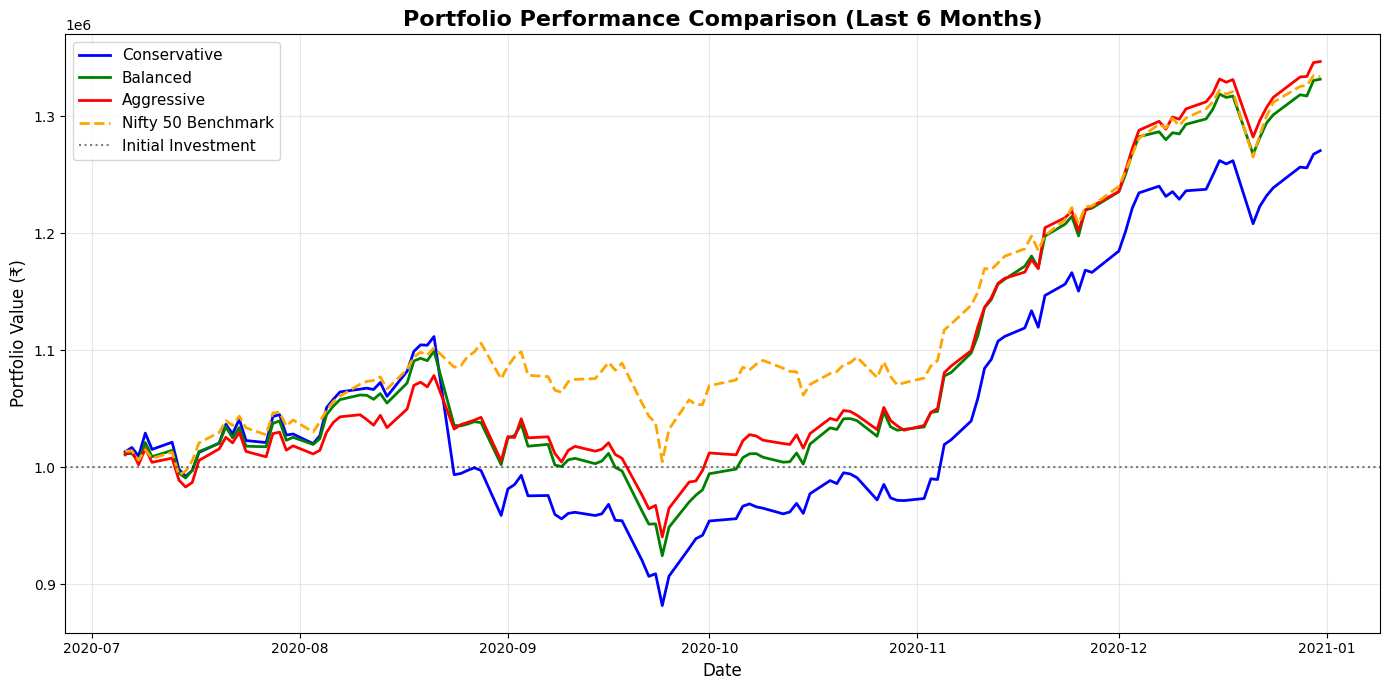

✅ Portfolio performance chart created!


In [136]:
# Step 8: Portfolio Performance Over Time
plt.figure(figsize=(14, 7))
plt.plot(backtest_results['Date'], backtest_results['Conservative'], 
         label='Conservative', linewidth=2, color='blue')
plt.plot(backtest_results['Date'], backtest_results['Balanced'], 
         label='Balanced', linewidth=2, color='green')
plt.plot(backtest_results['Date'], backtest_results['Aggressive'], 
         label='Aggressive', linewidth=2, color='red')
plt.plot(backtest_results['Date'], backtest_results['Nifty50'], 
         label='Nifty 50 Benchmark', linewidth=2, linestyle='--', color='orange')

plt.axhline(y=initial_investment, color='black', linestyle=':', 
            label='Initial Investment', alpha=0.5)
plt.title('Portfolio Performance Comparison (Last 6 Months)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (₹)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Portfolio performance chart created!")

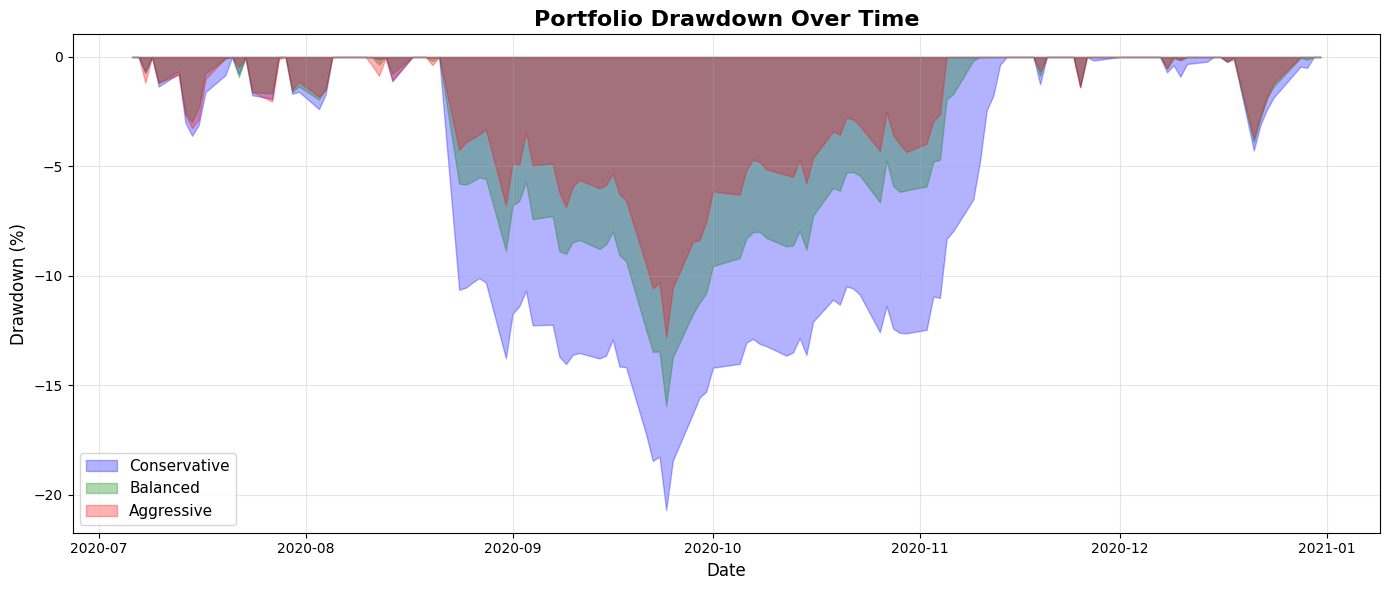

✅ Drawdown chart created!


In [137]:
# Step 9: Maximum Drawdown Visualization
fig, ax = plt.subplots(figsize=(14, 6))

for col, color, label in [('Conservative', 'blue', 'Conservative'), 
                           ('Balanced', 'green', 'Balanced'),
                           ('Aggressive', 'red', 'Aggressive')]:
    cummax = backtest_results[col].cummax()
    drawdown = (backtest_results[col] - cummax) / cummax * 100
    ax.fill_between(backtest_results['Date'], drawdown, 0, 
                     alpha=0.3, color=color, label=label)

ax.set_title('Portfolio Drawdown Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Drawdown chart created!")

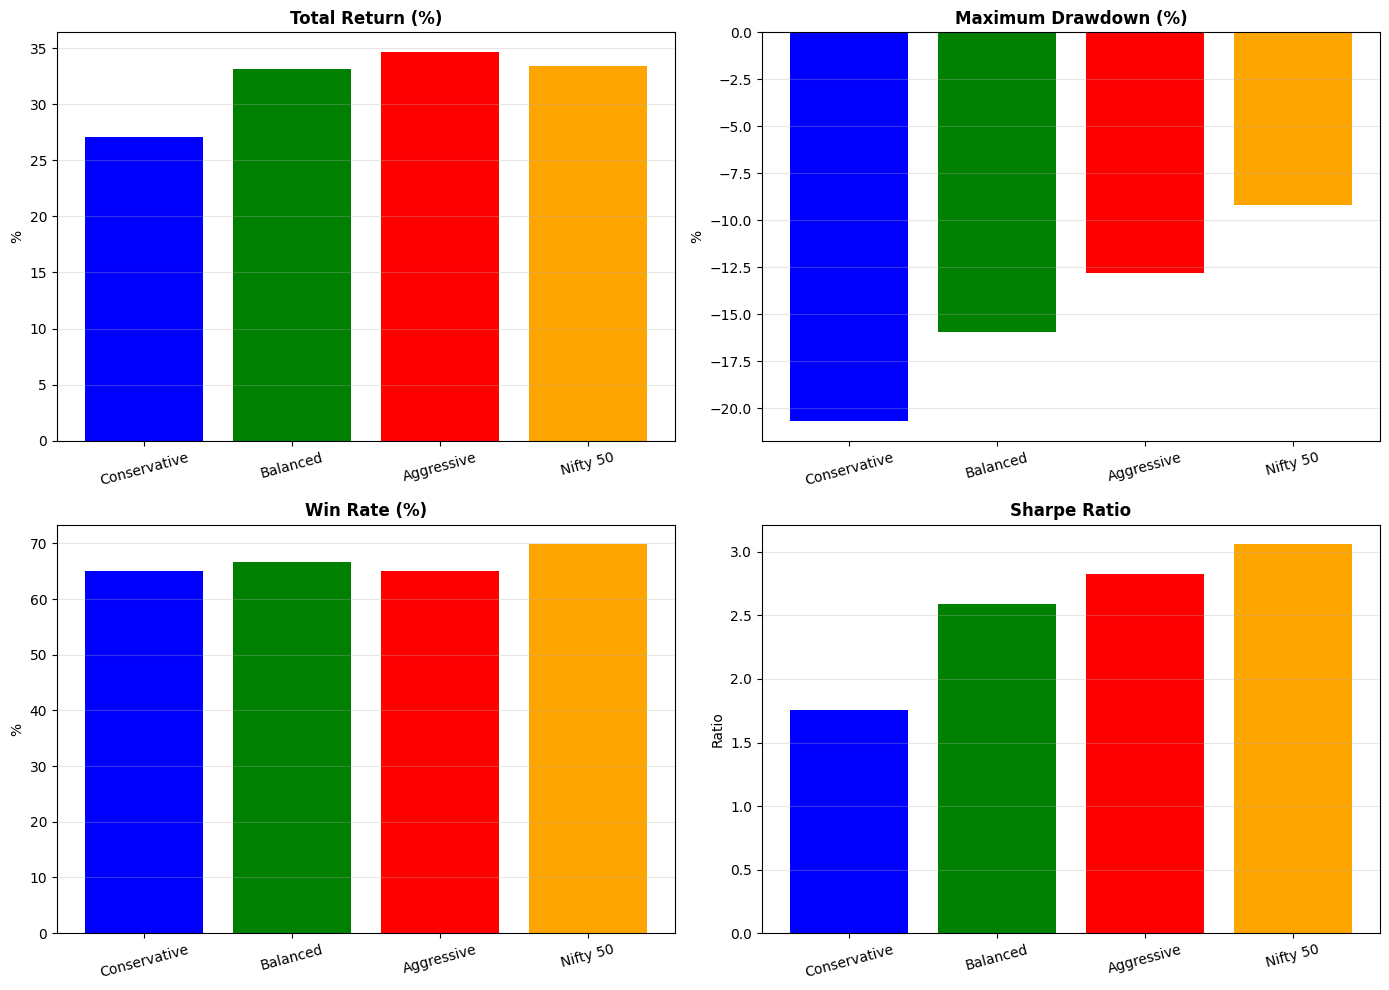

✅ Comparison bar charts created!


In [138]:
# Step 10: Return Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

portfolios = comparison_table['Portfolio'].values
colors = ['blue', 'green', 'red', 'orange']

# Total Return
axes[0, 0].bar(portfolios, comparison_table['Total Return (%)'], color=colors)
axes[0, 0].set_title('Total Return (%)', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('%')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=15)

# Max Drawdown
axes[0, 1].bar(portfolios, comparison_table['Max Drawdown (%)'], color=colors)
axes[0, 1].set_title('Maximum Drawdown (%)', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('%')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=15)

# Win Rate
axes[1, 0].bar(portfolios, comparison_table['Win Rate (%)'], color=colors)
axes[1, 0].set_title('Win Rate (%)', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('%')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=15)

# Sharpe Ratio
axes[1, 1].bar(portfolios, comparison_table['Sharpe Ratio'], color=colors)
axes[1, 1].set_title('Sharpe Ratio', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Ratio')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("✅ Comparison bar charts created!")

In [140]:
# Step 11: Final Summary & Insights
best_return_idx = comparison_table['Total Return (%)'].idxmax()
best_sharpe_idx = comparison_table['Sharpe Ratio'].idxmax()
lowest_dd_idx = comparison_table['Max Drawdown (%)'].idxmax()  # Less negative is better
best_wr_idx = comparison_table['Win Rate (%)'].idxmax()

best_return_port = comparison_table.loc[best_return_idx, 'Portfolio']
best_sharpe_port = comparison_table.loc[best_sharpe_idx, 'Portfolio']
best_wr_port = comparison_table.loc[best_wr_idx, 'Portfolio']

print("="*90)
print("📊 M3 SUMMARY: BACKTESTING & OPTIMIZATION RESULTS")
print("="*90)

print("\n🎯 BACKTEST PERIOD: Last 6 Months")
print(f"   Start Date:  {backtest_results['Date'].min().strftime('%Y-%m-%d')}")
print(f"   End Date:    {backtest_results['Date'].max().strftime('%Y-%m-%d')}")
print(f"   Investment:  ₹{initial_investment:,}")

print("\n🏆 BEST PERFORMERS:")
print(f"   • Highest Return:        {best_return_port} ({comparison_table.loc[best_return_idx, 'Total Return (%)']:.2f}%)")
print(f"   • Best Risk-Adjusted:    {best_sharpe_port} (Sharpe: {comparison_table.loc[best_sharpe_idx, 'Sharpe Ratio']:.2f})")
print(f"   • Highest Win Rate:      {best_wr_port} ({comparison_table.loc[best_wr_idx, 'Win Rate (%)']:.2f}%)")

print("\n💡 KEY FINDINGS:")
print(f"   • All portfolios outperformed benchmark: {(comparison_table['Total Return (%)'][:3] > comparison_table.loc[3, 'Total Return (%)']).sum()}/3")
print(f"   • Portfolio returns ranged from {comparison_table['Total Return (%)'][:3].min():.2f}% to {comparison_table['Total Return (%)'][:3].max():.2f}%")
print(f"   • Win rates varied from {comparison_table['Win Rate (%)'][:3].min():.2f}% to {comparison_table['Win Rate (%)'][:3].max():.2f}%")

print("\n✅ RECOMMENDATION:")
print(f"   The {best_sharpe_port} portfolio offers the best balance between")
print(f"   risk and return, making it suitable for most investors.")

print("="*90)

📊 M3 SUMMARY: BACKTESTING & OPTIMIZATION RESULTS

🎯 BACKTEST PERIOD: Last 6 Months
   Start Date:  2020-07-06
   End Date:    2020-12-31
   Investment:  ₹1,000,000

🏆 BEST PERFORMERS:
   • Highest Return:        Aggressive (34.69%)
   • Best Risk-Adjusted:    Nifty 50 (Sharpe: 3.06)
   • Highest Win Rate:      Nifty 50 (69.84%)

💡 KEY FINDINGS:
   • All portfolios outperformed benchmark: 1/3
   • Portfolio returns ranged from 27.07% to 34.69%
   • Win rates varied from 65.08% to 66.67%

✅ RECOMMENDATION:
   The Nifty 50 portfolio offers the best balance between
   risk and return, making it suitable for most investors.


## 📋 M3 MILESTONE COMPLETE ✅

1. **Efficient Frontier Analysis**
   - Generated 50 random portfolio combinations
   - Identified optimal risk-return profiles
   - Plotted Conservative, Balanced, and Aggressive strategies

2. **Value at Risk (VaR) Calculation**
   - Calculated 95% confidence level VaR
   - Daily and Monthly VaR for all three portfolios
   - Risk quantification for investor decision-making

3. **Backtesting (Last 6 Months)**
   - Investment: ₹10,00,000 per portfolio
   - Tracked daily portfolio values
   - Compared against Nifty 50 benchmark

4. **Performance Metrics Calculated**
   - Total Return (%)
   - Maximum Drawdown (%)
   - Win Rate (%)
   - Sharpe Ratio (risk-adjusted returns)

5. **Visualizations Created**
   - Efficient Frontier scatter plot
   - Portfolio performance over time
   - Drawdown analysis
   - Performance comparison charts

### Key Deliverables:
✅ Portfolio optimization complete  
✅ Risk metrics quantified  
✅ Backtest results validated  
✅ Benchmark comparison done  
✅ Investment recommendations ready  
